In [1]:
import pandas as pd
import os
import sys
import json
from pathlib import Path
import numpy as np

# Notebook is in notebooks/, so repo root is parent
REPO_ROOT = Path.cwd().parent
SRC_PATH = REPO_ROOT / "src"

# Insert src at the front of sys.path so imports work
sys.path.insert(0, str(SRC_PATH))

In [2]:
from preprocessing.ecg_preprocessing import load_ecg_data

# Get repo root relative to the current notebook
repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Load static preprocessing config
config_path = os.path.join(repo_root, "configs", "ecg_preprocessing_params.json")
with open(config_path, "r") as f:
    config = json.load(f)

# Set input and output directories
raw_dir = os.path.join(repo_root, config["paths"]["in_dir"])
processed_dir = os.path.join(repo_root, config["paths"]["processed_dir"])

# Pass directories to load function
ecg_record_list_df, machine_measurements_df, encounter_df = load_ecg_data(raw_dir, processed_dir, config)

In [3]:
ecg_meta = pd.read_csv(processed_dir + 'ecg_data.csv')

In [4]:
ecg_meta.columns

Index(['subject_id', 'study_id', 'file_name', 'ecg_time', 'path', 'hadm_id',
       'ed_stay_id', 'icu_stay_id', 'in_hosp', 'in_ed', 'in_icu',
       'icu_within_12hrs', 'icu_within_24hrs', 'cart_id', 'bandwidth',
       'filtering', 'rr_interval', 'p_onset', 'p_end', 'qrs_onset', 'qrs_end',
       't_end', 'p_axis', 'qrs_axis', 't_axis', 'full_report', 'sinus_rhythm',
       'sinus_bradycardia', 'sinus_tachycardia', 'atrial_fibrillation',
       'atrial_flutter', 'supraventricular_tachycardia',
       'ventricular_tachycardia', 'idioventricular_rhythm',
       'bundle_branch_block', 'right_bundle_branch_block',
       'left_bundle_branch_block', 'av_block',
       'left_anterior_fascicular_block', 'left_posterior_fascicular_block',
       'intraventricular_conduction_delay', 'aberrant_conduction',
       'left_ventricular_hypertrophy', 'right_ventricular_hypertrophy',
       'biatrial_enlargement', 'left_atrial_enlargement',
       'right_atrial_enlargement', 'axis_deviation', 'low_qr

In [5]:
ecg_meta['path']

0         files/p1659/p16598616/s40000035/40000035
1         files/p1837/p18370366/s40000084/40000084
2         files/p1257/p12576058/s40000115/40000115
3         files/p1469/p14691089/s40000143/40000143
4         files/p1608/p16089780/s40000152/40000152
                            ...                   
403116    files/p1704/p17041592/s49999952/49999952
403117    files/p1009/p10091327/s49999953/49999953
403118    files/p1744/p17449417/s49999973/49999973
403119    files/p1836/p18362083/s49999980/49999980
403120    files/p1031/p10319873/s49999993/49999993
Name: path, Length: 403121, dtype: object

In [6]:
import subprocess
from pathlib import Path

import numpy as np
import torch
import wfdb
from scipy.signal import resample

### Requesting ECG Waveforms from MIMIC-IV-ECG

In [7]:
MIMIC_IV_ECG = "https://physionet.org/files/mimic-iv-ecg/1.0/"

def wget(url: str, out_path: Path):
    out_path.parent.mkdir(parents=True, exist_ok=True)
    cmd = ["wget", "-q", "-O", str(out_path), url]
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        raise RuntimeError(f"wget failed:\n{result.stderr}")

def ensure_mimic_record(rel_path: str, wave_root: Path) -> Path:
    """
    rel_path example:
      files/p10001725/s41420867/41420867

    returns:
      local base path WITHOUT extension
    """
    base = wave_root / rel_path
    hea = base.with_suffix(".hea")
    dat = base.with_suffix(".dat")

    if not hea.exists():
        wget(f"{MIMIC_IV_ECG}/{rel_path}.hea", hea)
    if not dat.exists():
        wget(f"{MIMIC_IV_ECG}/{rel_path}.dat", dat)

    return base

def load_mimic_ecg(record_base: Path):
    """
    record_base: path WITHOUT .hea/.dat
    returns:
      x_Tx12: np.ndarray (T, 12)
      fs: float
    """
    rec = wfdb.rdrecord(str(record_base))
    x_Tx12 = rec.p_signal.astype(np.float32)
    fs = float(rec.fs)
    return x_Tx12, fs

## Importing HuBERT-ECG to Encode Raw Waveforms

In [22]:
def _zscore_per_lead(x_5s_500x12: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    """
    x_5s_500x12: (500, 12)
    returns: (12, 500) float32
    """
    # Optional: prevent NaNs/Infs from propagating
    x_5s_500x12 = np.nan_to_num(x_5s_500x12, nan=0.0, posinf=0.0, neginf=0.0)

    mu = x_5s_500x12.mean(axis=0, keepdims=True)
    sd = x_5s_500x12.std(axis=0, keepdims=True) + eps
    x_norm = (x_5s_500x12 - mu) / sd
    return x_norm.T.astype(np.float32)  # (12, 500)

def preprocess_for_hubert(x_Tx12: np.ndarray, fs: float) -> np.ndarray:
    """
      Input:  x_Tx12 (T, 12) at fs (e.g., 500 Hz, 10 seconds => T=5000)
      Output: (2, 12, 500) float32
              clip 0 = first 5s, clip 1 = second 5s (after resampling to 100 Hz)
    """
    target_fs = 100.0

    # resample to 100 Hz
    T_target = int(round(x_Tx12.shape[0] * target_fs / fs))
    x_100 = resample(x_Tx12, T_target, axis=0).astype(np.float32)  # (T_target, 12)

    crop_len = int(5 * target_fs)  # 500 samples @ 100 Hz

    # If we have >= 10s after resampling, take first and second contiguous 5s chunks
    if x_100.shape[0] >= 2 * crop_len:
        x_5s_a = x_100[0:crop_len]                 # (500, 12)
        x_5s_b = x_100[crop_len:2 * crop_len]      # (500, 12)
    else:
        # Fallback: center-crop one 5s window, then take a second window that overlaps
        # (so you always get two clips)
        start = max((x_100.shape[0] - crop_len) // 2, 0)
        x_5s_a = x_100[start:start + crop_len]

        # second clip: shift by half window if possible
        shift = crop_len // 2
        start2 = min(max(start + shift, 0), max(x_100.shape[0] - crop_len, 0))
        x_5s_b = x_100[start2:start2 + crop_len]

        # if still short (really tiny signals), pad to length crop_len
        def _pad_to_len(x):
            if x.shape[0] == crop_len:
                return x
            pad = crop_len - x.shape[0]
            return np.pad(x, ((0, pad), (0, 0)), mode="constant")
        x_5s_a = _pad_to_len(x_5s_a)
        x_5s_b = _pad_to_len(x_5s_b)

    clip_a = _zscore_per_lead(x_5s_a)  # (12, 500)
    clip_b = _zscore_per_lead(x_5s_b)  # (12, 500)

    return np.stack([clip_a, clip_b], axis=0)      # (2, 12, 500)

def combine_two_embeddings(emb_a, emb_b, mode: str = "mean"):
    """
    emb_a / emb_b can be:
      - (D,) pooled vectors
      - (T, D) frame-level embeddings
    Returns a single combined embedding.
    """
    ea = emb_a
    eb = emb_b

    # If frame-level, pool within each clip first
    if isinstance(ea, np.ndarray) and ea.ndim == 2:
        ea = ea.mean(axis=0)
    if isinstance(eb, np.ndarray) and eb.ndim == 2:
        eb = eb.mean(axis=0)

    if mode == "mean":
        return (ea + eb) / 2
    elif mode == "concat":
        return np.concatenate([ea, eb], axis=-1)
    else:
        raise ValueError(f"Unknown mode={mode}. Use 'mean' or 'concat'.")


# Importing HuBERT-ECG
from transformers import AutoModel

def load_hubert_ecg(device="cpu"):
    model = AutoModel.from_pretrained(
        "Edoardo-BS/hubert-ecg-small",
        trust_remote_code=True
    ).to(device)
    model.eval()
    return model

device = 'cpu'
hubert = load_hubert_ecg(device)

# Encodes raw MIMIC-IV-ECG into embeddings
@torch.no_grad()
def hubert_encode(x_12x500: np.ndarray, hubert_model, device="cpu") -> torch.Tensor:
    """
    x_12x500: (12, 500) numpy
    returns: (1, 512) torch
    """
    x = torch.tensor(
        x_12x500.reshape(1, -1),  # (1, 6000)
        dtype=torch.float32,
        device=device
    )

    out = hubert_model(x)
    z = out.last_hidden_state.mean(dim=1)  # (1, D)
    return z.cpu()

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

### Pipeline from Requesting Waveform to Producing Embeddings

In [23]:
def encode_mimic_record(
    rel_path: str,
    wave_root: Path,
    hubert_model,
    device="cpu"
) -> torch.Tensor:
    """
    rel_path: path from record_list.csv
    returns: (1, 512) embedding
    """
    record_base = ensure_mimic_record(rel_path, wave_root)
    x_Tx12, fs = load_mimic_ecg(record_base)
    clips_2x12x500 = preprocess_for_hubert(x_Tx12, fs)

    emb1 = hubert_encode(clips_2x12x500[0], hubert, device)
    emb2 = hubert_encode(clips_2x12x500[1], hubert, device)
    
    emb = (emb1 + emb2) / 2
    
    return emb

In [24]:
ECG_WAVEFORMS = Path(raw_dir + 'ecg-waveforms')
ECG_WAVEFORMS.mkdir(parents=True, exist_ok=True)

In [25]:
rel_path = ecg_meta.loc[0, 'path']
z = encode_mimic_record(rel_path, ECG_WAVEFORMS, hubert, device)

print(z.shape)
print(torch.norm(z))

torch.Size([1, 512])
tensor(11.8770)


In [26]:
rel_path = ecg_meta.loc[1, 'path']
z = encode_mimic_record(rel_path, ECG_WAVEFORMS, hubert, device)

print(z.shape)
print(torch.norm(z))

torch.Size([1, 512])
tensor(11.3800)


### Saving ECG Embeddings into Processed Data Folder

In [27]:
ECG_EMBEDDINGS = Path(processed_dir + 'ecg-embeddings')
ECG_EMBEDDINGS.mkdir(parents=True, exist_ok=True)

In [28]:
def embedding_path_from_rel(rel_path: str) -> Path:
    """
    rel_path example:
      files/p10001725/s41420867/41420867

    returns:
      Path to cached embedding file
    """
    fname = rel_path.replace("/", "__") + ".pt"
    return ECG_EMBEDDINGS / fname

def get_or_compute_embedding(
    rel_path: str,
    wave_root: Path,
    hubert_model,
    device="cpu"
) -> torch.Tensor:
    """
    Returns:
      embedding tensor of shape (1, D), loaded from cache if available
    """
    emb_path = embedding_path_from_rel(rel_path)

    # ---- cache hit ----
    if emb_path.exists():
        return torch.load(emb_path)

    # ---- cache miss ----
    record_base = ensure_mimic_record(rel_path, wave_root)
    x_Tx12, fs = load_mimic_ecg(record_base)
    x_12x500 = preprocess_for_hubert(x_Tx12, fs)
    z = hubert_encode(x_12x500, hubert_model, device)

    torch.save(z, emb_path)
    return z

In [29]:
rel = ecg_meta.loc[3, "path"]

z1 = get_or_compute_embedding(rel, ECG_WAVEFORMS, hubert, device)
z2 = get_or_compute_embedding(rel, ECG_WAVEFORMS, hubert, device)

print(torch.allclose(z1, z2)) 

True


## Import ECG-FM

## Final Pipeline Loop to Get All Waveforms + Create Embeddings

In [ ]:
from tqdm import tqdm

Z = []
paths = ecg_meta["path"].tolist()
records = []

for rel in tqdm(paths):
    try:
        z = get_or_compute_embedding(rel, ECG_WAVEFORMS, hubert, device)
        emb = z.squeeze(0) # (D,)
        records.append({
            "path": rel,
            "embedding": emb
        })
        Z.append(emb)
    except Exception as e:
        records.append({
            "path": rel,
            "embedding": None,
            "error": str(e)
        })

Z = torch.stack(Z)  # (N, D)
print(Z.shape)

  3%|█                                 | 12717/403121 [127:26:17<169:29:45,  1.56s/it]python3.10(14856) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3.10(14857) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
  3%|█                                 | 12718/403121 [127:26:19<171:10:29,  1.58s/it]python3.10(14858) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3.10(14859) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
  3%|█                                 | 12719/403121 [127:26:21<172:27:33,  1.59s/it]python3.10(14860) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3.10(14861) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
  3%|█                                 | 12720/403121 [127:26:22<174:08:21,  1.61s/it]python3.10(14862) MallocStackLogging: can't 

In [31]:
rec_df = pd.DataFrame(records)
rec_df.head()

,path,embedding
0,files/p1887/p18877429/s44900362/44900362,"[tensor(-0.7348), tensor(-0.1130), tensor(-0.5..."
1,files/p1591/p15911597/s44599375/44599375,"[tensor(-0.0995), tensor(0.4504), tensor(-0.95..."
2,files/p1639/p16393593/s40951481/40951481,"[tensor(0.1884), tensor(0.8799), tensor(-0.566..."
3,files/p1854/p18543030/s44454160/44454160,"[tensor(-0.5405), tensor(0.7310), tensor(-0.46..."
4,files/p1459/p14598748/s45627432/45627432,"[tensor(-0.4451), tensor(0.5072), tensor(-1.01..."


In [32]:
ecg_emb_meta = ecg_meta.merge(
    rec_df,
    on="path",
    how="inner"
)
ecg_emb_meta.head()

,subject_id,study_id,file_name,ecg_time,path,hadm_id,ed_stay_id,icu_stay_id,in_hosp,in_ed,...,undetermined_rhythm,wpw_pattern,technical_error,lead_reversal,pericarditis,hyperkalemia,digitalis_effect,abnormal_p_waves,ventricular_response,embedding
0,11309915,40008660,40008660,2187-07-04 19:42:00,files/p1130/p11309915/s40008660/40008660,23987733.0,NaN,NaN,1,0,...,0,0,0,0,0,0,0,0,0,"[tensor(-0.1890), tensor(1.1622), tensor(-0.00..."
1,10933325,40034509,40034509,2167-03-27 13:39:00,files/p1093/p10933325/s40034509/40034509,28348106.0,NaN,[30079243],1,0,...,0,0,0,0,0,0,0,0,0,"[tensor(0.0316), tensor(0.8731), tensor(-0.652..."
2,13777050,40061910,40061910,2141-08-15 17:20:00,files/p1377/p13777050/s40061910/40061910,21764468.0,NaN,[36719086],1,0,...,0,0,0,0,0,0,0,0,0,"[tensor(-0.1482), tensor(0.6024), tensor(-0.59..."
3,11970980,40129239,40129239,2123-08-15 07:14:00,files/p1197/p11970980/s40129239/40129239,20814866.0,30230549.0,[37269345],1,0,...,0,0,0,0,0,0,0,0,0,"[tensor(-0.7323), tensor(1.0272), tensor(-0.86..."
4,18949819,40140211,40140211,2133-07-03 09:10:00,files/p1894/p18949819/s40140211/40140211,21821347.0,NaN,NaN,1,0,...,0,0,0,0,0,0,0,0,0,"[tensor(-0.0987), tensor(0.5700), tensor(-0.25..."


In [33]:
Z = np.stack(ecg_emb_meta["embedding"].values)  # (N, 512)
print(Z.shape)

(200, 512)


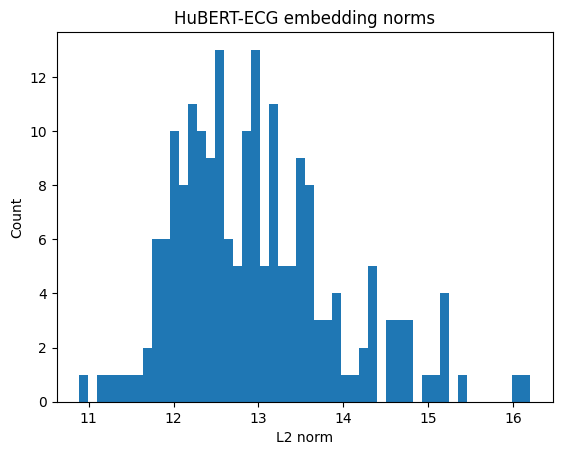

In [34]:
import matplotlib.pyplot as plt

norms = np.linalg.norm(Z, axis=1)

plt.hist(norms, bins=50)
plt.title("HuBERT-ECG embedding norms")
plt.xlabel("L2 norm")
plt.ylabel("Count")
plt.show()

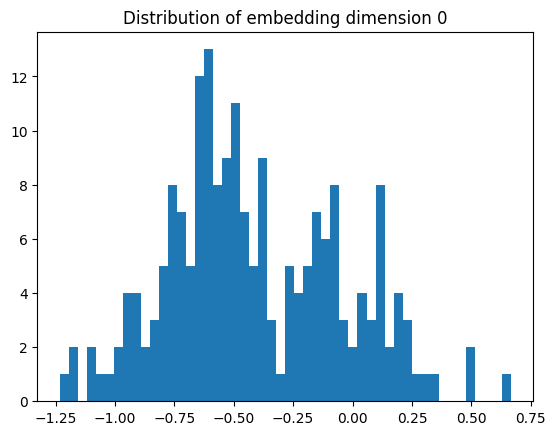

In [35]:
plt.hist(Z[:, 0], bins=50)
plt.title("Distribution of embedding dimension 0")
plt.show()

In [38]:
nan_rows = np.isnan(Z).any(axis=1)
print("num rows:", Z.shape[0])
print("rows with any NaN:", nan_rows.sum())
print("percent:", nan_rows.mean())

num rows: 200
rows with any NaN: 5
percent: 0.025


In [39]:
nan_rows.sum()

5

In [40]:
def emb_has_nan(emb):
    if emb is None:
        return True
    if torch.is_tensor(emb):
        return not torch.isfinite(emb).all().item()
    emb = np.asarray(emb)
    return not np.isfinite(emb).all()

bad_mask = ecg_emb_meta["embedding"].apply(emb_has_nan)

# 🔒 HARD ASSERTS
assert isinstance(bad_mask, pd.Series)
assert bad_mask.dtype == bool
assert bad_mask.index.equals(ecg_emb_meta.index)

bad_df = ecg_emb_meta.loc[bad_mask].copy()
good_df = ecg_emb_meta.loc[~bad_mask].copy()

print("bad:", len(bad_df), "good:", len(good_df))

bad: 5 good: 195


In [41]:
bad_df

,subject_id,study_id,file_name,ecg_time,path,hadm_id,ed_stay_id,icu_stay_id,in_hosp,in_ed,...,undetermined_rhythm,wpw_pattern,technical_error,lead_reversal,pericarditis,hyperkalemia,digitalis_effect,abnormal_p_waves,ventricular_response,embedding
7,17850007,40379494,40379494,2131-08-13 07:17:00,files/p1785/p17850007/s40379494/40379494,28093687.0,37595985.0,[35333615],1,0,...,0,0,0,0,0,0,0,0,0,"[tensor(nan), tensor(nan), tensor(nan), tensor..."
30,12974812,41122993,41122993,2176-03-06 13:48:00,files/p1297/p12974812/s41122993/41122993,20714176.0,39209745.0,"[32301271, 36323016]",1,0,...,0,0,0,0,0,0,0,0,0,"[tensor(nan), tensor(nan), tensor(nan), tensor..."
126,11184182,46065660,46065660,2154-01-19 10:23:00,files/p1118/p11184182/s46065660/46065660,22968010.0,38754175.0,NaN,0,1,...,0,0,0,0,0,0,0,0,0,"[tensor(nan), tensor(nan), tensor(nan), tensor..."
130,15537247,46533653,46533653,2122-01-16 09:00:00,files/p1553/p15537247/s46533653/46533653,22931335.0,NaN,NaN,1,0,...,0,0,0,0,0,0,0,0,0,"[tensor(nan), tensor(nan), tensor(nan), tensor..."
151,13686987,47385029,47385029,2116-10-13 03:24:00,files/p1368/p13686987/s47385029/47385029,21359519.0,NaN,NaN,1,0,...,0,0,0,0,0,0,0,0,0,"[tensor(nan), tensor(nan), tensor(nan), tensor..."


In [42]:
rel = bad_df.iloc[0]["path"]

record_base = ensure_mimic_record(rel, ECG_WAVEFORMS)
x_Tx12, fs = load_mimic_ecg(record_base)

print("fs:", fs)
print("raw shape:", x_Tx12.shape)
print("raw finite:", np.isfinite(x_Tx12).all())
print("raw min/max:", np.nanmin(x_Tx12), np.nanmax(x_Tx12))
print("raw std min per lead:", x_Tx12.std(axis=0).min())

fs: 500.0
raw shape: (5000, 12)
raw finite: False
raw min/max: -9.91 9.88
raw std min per lead: nan


In [43]:
x_12x500 = preprocess_for_hubert(x_Tx12, fs)

print("preprocessed finite:", np.isfinite(x_12x500).all())
print("pre std min per lead:", x_12x500.std(axis=1).min())
print("pre min/max:", np.nanmin(x_12x500), np.nanmax(x_12x500))

preprocessed finite: True
pre std min per lead: 0.039921436
pre min/max: -6.720591 7.000303


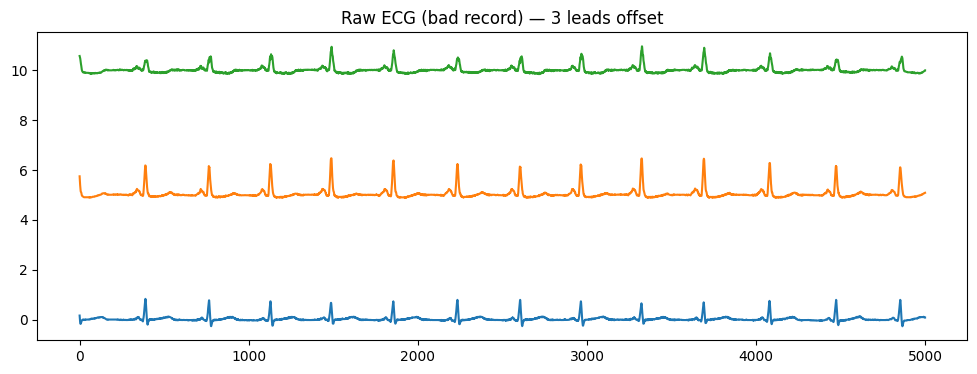

In [44]:
plt.figure(figsize=(12,4))
for i in range(3):
    plt.plot(x_Tx12[:, i] + i*5)
plt.title("Raw ECG (bad record) — 3 leads offset")
plt.show()

Some MIMIC-IV ECG waveform files contain sparse NaNs in one or more leads. HuBERT propagates these NaNs into the embedding. Therefore, because this is a data quality issue tracing back to the raw waveforms, we can safely drop these records as it a tiny portion of our dataset (<5%)

In [45]:
from sklearn.decomposition import PCA

Z = np.stack(good_df["embedding"].values)
pca = PCA(n_components=2)
Z_pca = pca.fit_transform(Z)

plt.scatter(Z_pca[:, 0], Z_pca[:, 1], s=5, alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("HuBERT-ECG embeddings (PCA)")
plt.show()

print("Explained variance:", pca.explained_variance_ratio_)

ImportError: cannot import name 'validate_data' from 'sklearn.utils.validation' (/Users/silver/miniforge3/lib/python3.10/site-packages/sklearn/utils/validation.py)

In [46]:
norms = np.linalg.norm(Z, axis=1)
np.corrcoef(norms, Z_pca[:, 0])[0, 1]

NameError: name 'Z_pca' is not defined

In [47]:
pca = PCA(n_components=2, random_state=0)
Z_pca = pca.fit_transform(Z)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained:", pca.explained_variance_ratio_.sum())

NameError: name 'PCA' is not defined

In [48]:
colors = good_df["abnormal_ecg"].fillna(0).values

plt.figure(figsize=(6, 5))
plt.scatter(
    Z_pca[:, 0],
    Z_pca[:, 1],
    c=colors,
    cmap="coolwarm",
    s=10,
    alpha=0.7
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA colored by abnormal_ecg")
plt.colorbar(label="abnormal_ecg")
plt.show()

NameError: name 'Z_pca' is not defined

<Figure size 600x500 with 0 Axes>

In [148]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

y = good_df["abnormal_ecg"].values
clf = LogisticRegression(max_iter=1000)
scores = cross_val_score(clf, Z, y, cv=5, scoring="roc_auc")
scores.mean()

0.8010303536619325